In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model

In [2]:
#plot 한글 적용
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [3]:
def getAssetsStock(tickers, startDate, endDate):
    
    dic = {}
    file_path = "../Data-collection/dailyStock"
    
    for ticker in tickers:
        ticker_df = pd.read_csv(f"{file_path}/{ticker}.csv", encoding="utf-8")
        ticker_df['Date'] = pd.to_datetime(ticker_df['Date'])
        ticker_df = ticker_df.set_index('Date')
        ticker_df = ticker_df.loc[startDate:endDate]
        
        dic[ticker] = 100 * ticker_df['adj_close'].pct_change().dropna()
    
    returns_df = pd.DataFrame(dic)
    
    return returns_df.dropna()

### 데이터 불러오기(2015~2018년도)

In [4]:
RISKY_ASSETS = ["AAPL", "GOOG", "MSFT"]
N = len(RISKY_ASSETS)
START_DATE = "2015-01-01"
END_DATE = "2018-12-31"

In [5]:
returns = getAssetsStock(RISKY_ASSETS, START_DATE, END_DATE)

### 수익률 도식화

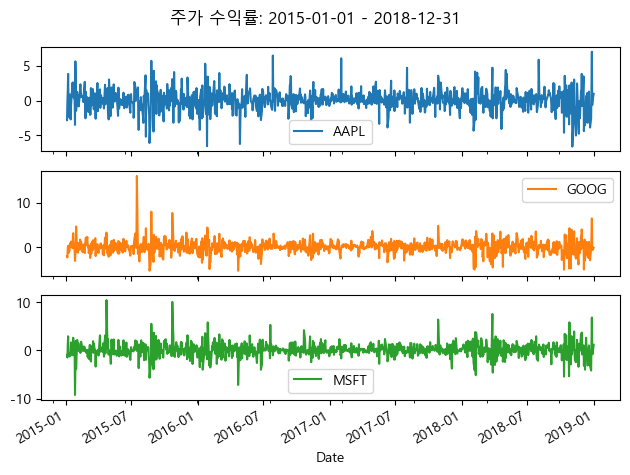

In [6]:
returns.plot(subplots=True, 
             title=f'주가 수익률: {START_DATE} - {END_DATE}')

plt.tight_layout()
plt.show()

### 단변량 GARCH 모델 생성

In [7]:
coeffs = []      #분석결과
cond_vol = []    #일별 조건부 변동성
std_resids = []  #일변 표준화 잔차
models = []

In [8]:
for asset in returns.columns:
    # specify and fit the model
    model = arch_model(returns[asset], mean='Constant', vol='GARCH', p=1, o=0, q=1).fit(update_freq=0, disp='off')
   
    coeffs.append(model.params)
    cond_vol.append(model.conditional_volatility)
    std_resids.append(model.resid / model.conditional_volatility)
    models.append(model)

In [9]:
coeffs_df = pd.DataFrame(coeffs, index=returns.columns)
cond_vol_df = pd.DataFrame(cond_vol).transpose().set_axis(returns.columns, axis='columns')
std_resids_df = pd.DataFrame(std_resids).transpose().set_axis(returns.columns, axis='columns')

### 상관관계 분석

In [10]:
# 행렬곱에 관측수를 나누어 상관계수 산출
R = std_resids_df.transpose().dot(std_resids_df).div(len(std_resids_df))

### 공분산의 1단계 선행 예측

In [11]:
diag = []
D = np.zeros((N, N))

# 각 자산의 1일 후 조건부 분산을 예측
for model in models:
    diag.append(model.forecast(horizon=1).variance.values[-1][0]) 

#분산을 표준편차로 변환
diag = np.sqrt(np.array(diag))

#대각행렬로 표준쳔차값 입력
np.fill_diagonal(D, diag)

#각 종목의 예측 변동성(D)와 종목 간 상관관계(R)을 결합해서, 다음 시점의 조건부 공분산 행렬(H) 생성
H = np.matmul(np.matmul(D, R.values), D)

H

array([[5.76557311, 2.61563873, 2.86275879],
       [2.61563873, 4.77988806, 3.32221883],
       [2.86275879, 3.32221883, 5.33736769]])